# Session 4: Feature Engineering, Threshold Optimization, and Interpretable Logistic Regression

This section builds a **leakage-safe, interpretable, and business-oriented baseline model** for predicting NYC restaurant inspection failure.

The goal of this part is not to repeat the EDA, PCA, or KMeans analysis from Part B. Instead, we transform available **pre-inspection information** into a supervised learning pipeline that helps identify high-risk restaurants before inspections take place.

### Target Variable

**failed = 1** → the restaurant failed the inspection  
**failed = 0** → the restaurant passed the inspection

Our objective is not only to predict failure, but also to support **inspection prioritization and public-health risk control**. Since missing a truly risky restaurant (False Negative) is more costly than performing one extra inspection (False Positive), recall and threshold tuning are especially important.

---

### Leakage Prevention

To avoid **target leakage**, variables directly related to current inspection outcomes are excluded:

`score`, `grade`, `violation_count`, `critical_count`, and `score_trend`

These variables are only observed during or after inspection and would create unrealistic prediction performance.

Instead, we focus on leakage-safe predictors such as:

- restaurant profile information  
- Yelp reputation signals  
- complaint intensity  
- inspection history  
- weather and seasonality  
- borough-level socioeconomic context

---

### Feature Engineering

We construct several **business-driven features** to improve predictive power:

- **poor_history_flag** → prior failure or high previous inspection score
- **complaint_intensity** → combined food, rodent, and food-safety complaint pressure
- **complaint_density** → complaint volume normalized by borough population
- **high_complaint_flag** → unusually high complaint environment
- **log_yelp_reviews** → Yelp visibility and review-volume signal

---

### Why Logistic Regression

Logistic Regression is selected because **interpretability is critical** in regulatory decision systems.

Compared with black-box models, it provides:

- transparent coefficient interpretation  
- clear risk factor explanation  
- easier policy communication

This makes it a strong baseline for inspection risk prediction.

---

### Threshold Tuning

Instead of using the default threshold of **0.50**, we apply **threshold tuning** to improve Recall and F1-score.

Because false negatives are costly in public-health settings, optimizing the classification threshold helps better identify truly risky restaurants.

Restaurants with predicted failure probability above the optimized threshold are flagged as:

### High-Priority Inspection Candidates

This makes the model a practical **inspection prioritization system**, not just a simple classifier.

---

This section directly addresses the project requirements on **feature engineering, preprocessing, supervised modeling, evaluation, interpretation, and business recommendation**.

In [1]:
import os
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import joblib

from sklearn.model_selection import GridSearchCV, StratifiedKFold
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    classification_report,
    ConfusionMatrixDisplay,
    RocCurveDisplay
)

os.makedirs("outputs", exist_ok=True)
os.makedirs("models", exist_ok=True)
os.makedirs("figures", exist_ok=True)

## 1. Load Cleaned Data

The input file is the cleaned restaurant inspection dataset produced by the earlier data cleaning pipeline. The full project dataset was constructed from multiple sources, including NYC restaurant inspection records, Yelp business data, weather data, 311 food-related complaints, and census demographics. :contentReference[oaicite:1]{index=1}

Although Part B created PCA and KMeans outputs, this section does **not** reuse clustering labels if those labels were generated using current inspection outcome variables. This keeps the supervised model strictly leakage-safe.

In [2]:
clean_path = '/Users/apple/Desktop/Final 4:29 Pre 5:5 ddl/Data/restaurant_clean.csv'

if os.path.exists(clean_path):
    df = pd.read_csv(clean_path, low_memory=False)
    print("Loaded:", clean_path)
else:
    df = pd.read_csv("/mnt/data/restaurant_clean.csv", low_memory=False)
    print("Loaded from /mnt/data/restaurant_clean.csv")

df["inspection_date"] = pd.to_datetime(df["inspection_date"], errors="coerce")

print("Data shape:", df.shape)
df.head()

Loaded: /Users/apple/Desktop/Final 4:29 Pre 5:5 ddl/Data/restaurant_clean.csv
Data shape: (41556, 52)


,camis,inspection_date,dba,boro,zipcode,cuisine,score,grade,action,violation_count,...,score_trend,grade_available,has_yelp,is_first_inspection,has_history,cuisine_grouped,yelp_category_primary,white_pct,score_bucket,has_location
0,30075445,2023-08-01,MORRIS PARK BAKE SHOP,BRONX,10462,Bakery Products/Desserts,38.0,NaN,Violations were cited in the following area(s).,3,...,0.0,0,1,1,0,Bakery Products/Desserts,bakeries,0.179270,C,1
1,30075445,2023-08-22,MORRIS PARK BAKE SHOP,BRONX,10462,Bakery Products/Desserts,12.0,A,Violations were cited in the following area(s).,3,...,-26.0,1,1,0,1,Bakery Products/Desserts,bakeries,0.179270,A,1
2,30075445,2024-11-08,MORRIS PARK BAKE SHOP,BRONX,10462,Bakery Products/Desserts,10.0,A,Violations were cited in the following area(s).,3,...,-2.0,1,1,0,1,Bakery Products/Desserts,bakeries,0.179270,A,1
3,30191841,2023-04-23,D.J. REYNOLDS,MANHATTAN,10019,Irish,10.0,A,Violations were cited in the following area(s).,2,...,0.0,1,1,1,0,Other,irish,0.512163,A,1
4,30191841,2024-11-20,D.J. REYNOLDS,MANHATTAN,10019,Irish,24.0,NaN,Violations were cited in the following area(s).,6,...,14.0,0,1,0,1,Other,irish,0.512163,B,1


## 2. Target Definition and Class Balance

The supervised learning target is `failed`, a binary indicator of inspection failure.

Before modeling, we check the class distribution. This is important because restaurant inspection failure is not evenly distributed across the data. If failures are the minority class, accuracy alone can be misleading.

In [3]:
target_col = "failed"

print("Target distribution:")
print(df[target_col].value_counts(dropna=False))

print("\nTarget rate:")
print(df[target_col].value_counts(normalize=True))

print("\nFailure rate:")
print(df[target_col].mean())

Target distribution:
failed
0    34074
1     7482
Name: count, dtype: int64

Target rate:
failed
0    0.819954
1    0.180046
Name: proportion, dtype: float64

Failure rate:
0.18004620271440946


## 3. Leakage Prevention

A central concern in this section is **target leakage**.

The target `failed` was created from current inspection outcomes. Therefore, the following variables are excluded:

- `score`: directly determines failure status
- `grade`: directly reflects the inspection outcome
- `score_bucket`: derived from score
- `action`: post-inspection administrative field
- `violation_count`: observed during/current inspection
- `critical_count`: observed during/current inspection
- `critical_ratio`: derived from current inspection violations
- `score_trend`: uses the current inspection score
- `cluster`: excluded because Part B clustering may use score or violation variables
- `camis`, `dba`: identifiers, not generalizable predictors
- `inspection_date`: raw date, replaced by engineered time features
- `latitude`, `longitude`: high missingness and not used directly
- `zipcode`: high cardinality; borough captures broader location context

This makes the prediction task more realistic: the model uses information that would be available **before** the final inspection outcome is known.

In [4]:
excluded_features = {
    "score": "Directly defines failed; using it would leak the target.",
    "grade": "Directly reflects inspection outcome.",
    "score_bucket": "Derived from score, therefore leaks target information.",
    "action": "Post-inspection administrative outcome.",
    "violation_count": "Current inspection violation count is only known during/after inspection.",
    "critical_count": "Current inspection critical violations are only known during/after inspection.",
    "critical_ratio": "Derived from current inspection violations.",
    "score_trend": "Uses current score, therefore leaks outcome information.",
    "cluster": "Part B cluster may use score/violation variables; excluded for leakage-safe modeling.",
    "camis": "Restaurant ID, not generalizable.",
    "dba": "Restaurant name, not generalizable.",
    "inspection_date": "Raw date replaced by engineered temporal features.",
    "latitude": "High missingness; not used directly.",
    "longitude": "High missingness; not used directly.",
    "zipcode": "High cardinality; borough captures broader location context."
}

leakage_audit = pd.DataFrame(
    excluded_features.items(),
    columns=["Excluded Feature", "Reason"]
)

leakage_audit.to_csv("outputs/leakage_audit.csv", index=False)
leakage_audit

,Excluded Feature,Reason
0,score,Directly defines failed; using it would leak t...
1,grade,Directly reflects inspection outcome.
2,score_bucket,"Derived from score, therefore leaks target inf..."
3,action,Post-inspection administrative outcome.
4,violation_count,Current inspection violation count is only kno...
5,critical_count,Current inspection critical violations are onl...
6,critical_ratio,Derived from current inspection violations.
7,score_trend,"Uses current score, therefore leaks outcome in..."
8,cluster,Part B cluster may use score/violation variabl...
9,camis,"Restaurant ID, not generalizable."


## 4. Leakage-Safe Feature Engineering

The feature engineering strategy uses variables that are available before the inspection outcome is known.

The engineered features are grouped into five categories:

1. **Historical Risk Features**  
   Prior score, prior failure, inspection history, and first-inspection status.

2. **Complaint Environment Features**  
   Food complaints, rodent complaints, food safety complaints, complaint intensity, and complaint density.

3. **Temporal Context Features**  
   Month and day-of-week cyclical encodings, weekend indicator, and summer indicator.

4. **Weather and Demographic Features**  
   Weather conditions and borough-level census information.

5. **Visibility and Market Signals**  
   Yelp availability, Yelp review volume, price level, and location availability.

This feature design supports the project requirement that preprocessing and feature engineering should improve downstream modeling while being justified by the problem context. :contentReference[oaicite:2]{index=2}

In [6]:
df_fe = df.copy()

# Historical risk features

df_fe["poor_history_flag"] = (
    (df_fe["prev_failed"] == 1) | (df_fe["prev_score"] >= 28)
).astype(int)


# Complaint environment features

df_fe["complaint_intensity"] = (
    df_fe["food_complaints_total"].fillna(0)
    + df_fe["rodent_complaints"].fillna(0)
    + df_fe["food_safety_complaints"].fillna(0)
)

df_fe["complaint_density"] = (
    df_fe["food_complaints_total"].fillna(0)
    / df_fe["total_population"].replace(0, np.nan)
) * 10000

df_fe["high_complaint_flag"] = (
    df_fe["food_complaints_total"]
    > df_fe["food_complaints_total"].quantile(0.75)
).astype(int)

# Temporal features

df_fe["month_sin"] = np.sin(2 * np.pi * df_fe["inspection_month"] / 12)
df_fe["month_cos"] = np.cos(2 * np.pi * df_fe["inspection_month"] / 12)

df_fe["dow_sin"] = np.sin(2 * np.pi * df_fe["inspection_dow"] / 7)
df_fe["dow_cos"] = np.cos(2 * np.pi * df_fe["inspection_dow"] / 7)

df_fe["summer_flag"] = df_fe["inspection_month"].isin([6, 7, 8]).astype(int)


# Yelp / visibility features

df_fe["log_yelp_reviews"] = np.log1p(df_fe["yelp_reviews"])

# Clean infinite values
df_fe.replace([np.inf, -np.inf], np.nan, inplace=True)

print("Feature engineering complete.")
print("Feature-engineered data shape:", df_fe.shape)

Feature engineering complete.
Feature-engineered data shape: (41556, 62)


## 5. Feature Selection

The final feature set excludes current inspection outcome variables and keeps only leakage-safe predictors.

The selected variables include:

- Historical inspection information available before the current outcome
- Complaint and civic environment variables
- Weather and temporal context
- Borough-level demographic variables
- Yelp visibility and review-volume signals
- Categorical context such as borough, cuisine group, and primary Yelp category

This creates a more realistic and generalizable prediction problem.

In [7]:
numeric_features = [
    # Historical information
    "prev_score",
    "prev_failed",
    "inspection_count",
    "poor_history_flag",
    "is_first_inspection",
    "has_history",

    # Complaint environment
    "food_complaints_total",
    "rodent_complaints",
    "food_safety_complaints",
    "complaint_intensity",
    "complaint_density",
    "high_complaint_flag",

    # Weather and temporal context
    "temp_mean",
    "precipitation_sum",
    "rain_sum",
    "snowfall_sum",
    "wind_speed_mean",
    "cloud_cover_mean",
    "month_sin",
    "month_cos",
    "dow_sin",
    "dow_cos",
    "summer_flag",
    "is_weekend",

    # Demographics
    "median_household_income",
    "total_population",
    "white_pct",

    # Yelp / visibility
    "has_yelp",
    "has_location",
    "log_yelp_reviews",
    "yelp_price"
]

categorical_features = [
    "boro",
    "cuisine_grouped",
    "yelp_category_primary"
]

# Keep only columns that exist
numeric_features = [col for col in numeric_features if col in df_fe.columns]
categorical_features = [col for col in categorical_features if col in df_fe.columns]

print("Number of numeric features:", len(numeric_features))
print(numeric_features)

print("\nNumber of categorical features:", len(categorical_features))
print(categorical_features)

Number of numeric features: 31
['prev_score', 'prev_failed', 'inspection_count', 'poor_history_flag', 'is_first_inspection', 'has_history', 'food_complaints_total', 'rodent_complaints', 'food_safety_complaints', 'complaint_intensity', 'complaint_density', 'high_complaint_flag', 'temp_mean', 'precipitation_sum', 'rain_sum', 'snowfall_sum', 'wind_speed_mean', 'cloud_cover_mean', 'month_sin', 'month_cos', 'dow_sin', 'dow_cos', 'summer_flag', 'is_weekend', 'median_household_income', 'total_population', 'white_pct', 'has_yelp', 'has_location', 'log_yelp_reviews', 'yelp_price']

Number of categorical features: 3
['boro', 'cuisine_grouped', 'yelp_category_primary']


## 6. Time-Based Train/Test Split

Instead of using a random split, this section uses a **time-based split**:

- **Training set:** inspections before January 1, 2024  
- **Test set:** inspections on or after January 1, 2024

This better simulates real-world deployment. In practice, a model would be trained on historical inspection data and then applied to future inspections.

This design also avoids mixing future observations into the training process.

In [8]:
model_df = df_fe.dropna(subset=[target_col, "inspection_date"]).copy()

train_df = model_df[model_df["inspection_date"] < "2024-01-01"].copy()
test_df = model_df[model_df["inspection_date"] >= "2024-01-01"].copy()

X_train = train_df[numeric_features + categorical_features]
y_train = train_df[target_col].astype(int)

X_test = test_df[numeric_features + categorical_features]
y_test = test_df[target_col].astype(int)

print("Train shape:", X_train.shape)
print("Test shape:", X_test.shape)

print("\nTrain failure rate:", y_train.mean())
print("Test failure rate:", y_test.mean())

Train shape: (17965, 34)
Test shape: (23591, 34)

Train failure rate: 0.17406067353186752
Test failure rate: 0.18460429824933236


## 7. Preprocessing Pipeline

The preprocessing pipeline is designed to be reproducible and leakage-safe.

For numeric features:

1. Missing values are imputed using the median.
2. Features are standardized using `StandardScaler`.

For categorical features:

1. Missing values are imputed using the most frequent category.
2. Variables are one-hot encoded.

Using `Pipeline` and `ColumnTransformer` ensures that all preprocessing steps are learned only from the training set and then applied consistently to the test set.

In [10]:
numeric_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

categorical_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(handle_unknown="ignore"))
])

preprocessor = ColumnTransformer(
    transformers=[
        ("num", numeric_transformer, numeric_features),
        ("cat", categorical_transformer, categorical_features)
    ]
)

## 8. Regularized Logistic Regression

Logistic Regression is used as an **interpretable baseline model**.

It is appropriate here because:

- The target is binary.
- The model provides interpretable coefficients.
- It creates a transparent benchmark for more complex models in Part D.
- It helps explain which risk signals are associated with higher inspection failure probability.

Because failed inspections are the minority class, we use:

**class_weight = "balanced"**

This reduces the tendency of the model to favor the majority class.

We also tune the regularization strength and penalty type using cross-validation.

In [12]:
logistic_pipeline = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("model", LogisticRegression(
        class_weight="balanced",
        solver="liblinear",
        max_iter=2000,
        random_state=42
    ))
])

param_grid = {
    "model__C": [0.01, 0.1, 1.0, 10.0],
    "model__penalty": ["l1", "l2"]
}

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

grid_search = GridSearchCV(
    estimator=logistic_pipeline,
    param_grid=param_grid,
    scoring="roc_auc",
    cv=cv,
    n_jobs=-1,
    verbose=1
)

grid_search.fit(X_train, y_train)

best_logistic_model = grid_search.best_estimator_

print("Best parameters:", grid_search.best_params_)
print("Best CV ROC-AUC:", grid_search.best_score_)

Fitting 5 folds for each of 8 candidates, totalling 40 fits
Best parameters: {'model__C': 0.1, 'model__penalty': 'l2'}
Best CV ROC-AUC: 0.6192273980907028


## 9. Model Evaluation at Default Threshold

Accuracy alone is not sufficient because the target is imbalanced.

In this public-health setting, **recall for failed inspections is especially important**. A false negative means the model predicts that a restaurant will pass, but it actually fails. This is more serious than a false positive because a risky restaurant may be missed.

Therefore, the model is evaluated using:

- Accuracy
- Precision
- Recall
- F1-score
- ROC-AUC
- Confusion matrix
- ROC curve

In [13]:
y_prob = best_logistic_model.predict_proba(X_test)[:, 1]
y_pred_default = (y_prob >= 0.50).astype(int)

metrics_default = {
    "Accuracy": accuracy_score(y_test, y_pred_default),
    "Precision": precision_score(y_test, y_pred_default, zero_division=0),
    "Recall": recall_score(y_test, y_pred_default, zero_division=0),
    "F1-score": f1_score(y_test, y_pred_default, zero_division=0),
    "ROC-AUC": roc_auc_score(y_test, y_prob)
}

metrics_default_df = pd.DataFrame(
    metrics_default,
    index=["Logistic Regression | Threshold 0.50"]
)

metrics_default_df

,Accuracy,Precision,Recall,F1-score,ROC-AUC
Logistic Regression | Threshold 0.50,0.621678,0.25308,0.537773,0.344184,0.630463


In [14]:
print(classification_report(y_test, y_pred_default, target_names=["Pass", "Fail"]))

              precision    recall  f1-score   support

        Pass       0.86      0.64      0.73     19236
        Fail       0.25      0.54      0.34      4355

    accuracy                           0.62     23591
   macro avg       0.56      0.59      0.54     23591
weighted avg       0.75      0.62      0.66     23591



### Baseline Comparison: Why Accuracy Alone Is Misleading

Because failed inspections account for only about 18% of the data, a naive model that always predicts **Pass** can still achieve high accuracy. However, such a model would identify **zero failing restaurants**, making it useless for public-health risk screening.

Therefore, we compare Logistic Regression against a simple majority-class baseline. The goal is not only to improve accuracy, but to demonstrate meaningful improvement in **Recall**, **F1-score**, and **ROC-AUC**, which are more relevant for identifying high-risk restaurants.

In [24]:
# Majority-class baseline: always predict Pass = 0
y_pred_baseline = np.zeros_like(y_test)
y_prob_baseline = np.zeros_like(y_test, dtype=float)

baseline_metrics = {
    "Accuracy": accuracy_score(y_test, y_pred_baseline),
    "Precision": precision_score(y_test, y_pred_baseline, zero_division=0),
    "Recall": recall_score(y_test, y_pred_baseline, zero_division=0),
    "F1-score": f1_score(y_test, y_pred_baseline, zero_division=0),
    "ROC-AUC": 0.50
}

baseline_comparison = pd.DataFrame(
    [baseline_metrics, metrics_default],
    index=["Majority-Class Baseline", "Logistic Regression | Threshold 0.50"]
)

baseline_comparison.to_csv("outputs/baseline_vs_logistic_metrics.csv")
baseline_comparison

,Accuracy,Precision,Recall,F1-score,ROC-AUC
Majority-Class Baseline,0.815396,0.00000,0.000000,0.000000,0.500000
Logistic Regression | Threshold 0.50,0.621678,0.25308,0.537773,0.344184,0.630463


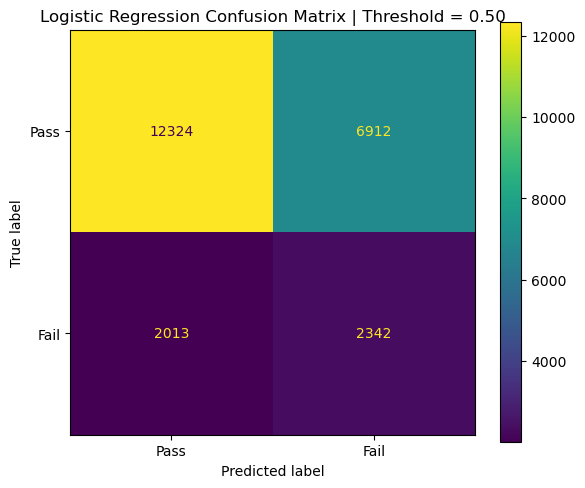

In [15]:
cm_default = confusion_matrix(y_test, y_pred_default)

fig, ax = plt.subplots(figsize=(6, 5))
disp = ConfusionMatrixDisplay(cm_default, display_labels=["Pass", "Fail"])
disp.plot(ax=ax, values_format="d")
plt.title("Logistic Regression Confusion Matrix | Threshold = 0.50")
plt.tight_layout()
plt.savefig("figures/logistic_confusion_matrix_default.png", dpi=300, bbox_inches="tight")
plt.show()

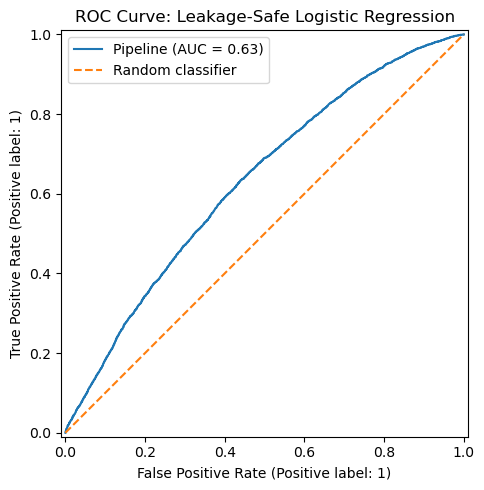

In [16]:
fig, ax = plt.subplots(figsize=(6, 5))
RocCurveDisplay.from_estimator(best_logistic_model, X_test, y_test, ax=ax)
plt.plot([0, 1], [0, 1], linestyle="--", label="Random classifier")
plt.title("ROC Curve: Leakage-Safe Logistic Regression")
plt.legend()
plt.tight_layout()
plt.savefig("figures/logistic_roc_curve.png", dpi=300, bbox_inches="tight")
plt.show()

## 10. Threshold Tuning

### Why F1-score for Threshold Selection

Although **Recall** is especially important in this public-health setting, maximizing recall alone may create too many false positives and overwhelm limited inspection resources.

At the same time, **Precision** also matters because unnecessary high-risk flags can create extra regulatory workload.

Therefore, we use **F1-score** as the threshold selection criterion because it balances Precision and Recall. This makes the threshold choice more practical for inspection prioritization: the model should catch more truly failing restaurants while still maintaining reasonable inspection efficiency.

The default threshold of 0.50 is not always optimal for imbalanced classification.

Because missing a failing restaurant may create public-health risk, we evaluate different classification thresholds and compare precision, recall, and F1-score.

This allows the model threshold to better reflect the decision context rather than relying on the default cutoff.

In [17]:
thresholds = np.arange(0.10, 0.91, 0.01)
threshold_results = []

for threshold in thresholds:
    y_pred_t = (y_prob >= threshold).astype(int)
    
    threshold_results.append({
        "threshold": threshold,
        "precision": precision_score(y_test, y_pred_t, zero_division=0),
        "recall": recall_score(y_test, y_pred_t, zero_division=0),
        "f1": f1_score(y_test, y_pred_t, zero_division=0)
    })

threshold_df = pd.DataFrame(threshold_results)

best_f1_row = threshold_df.loc[threshold_df["f1"].idxmax()]
best_threshold = best_f1_row["threshold"]

print("Best threshold based on F1-score:")
print(best_f1_row)

Best threshold based on F1-score:
threshold    0.470000
precision    0.244770
recall       0.636739
f1           0.353609
Name: 37, dtype: float64


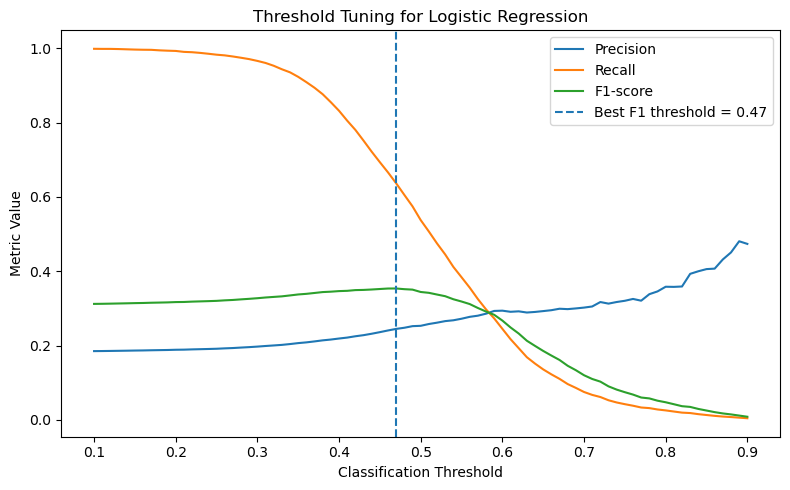

In [18]:
plt.figure(figsize=(8, 5))
plt.plot(threshold_df["threshold"], threshold_df["precision"], label="Precision")
plt.plot(threshold_df["threshold"], threshold_df["recall"], label="Recall")
plt.plot(threshold_df["threshold"], threshold_df["f1"], label="F1-score")

plt.axvline(
    best_threshold,
    linestyle="--",
    label=f"Best F1 threshold = {best_threshold:.2f}"
)

plt.xlabel("Classification Threshold")
plt.ylabel("Metric Value")
plt.title("Threshold Tuning for Logistic Regression")
plt.legend()
plt.tight_layout()
plt.savefig("figures/logistic_threshold_tuning.png", dpi=300, bbox_inches="tight")
plt.show()

In [19]:
y_pred_best = (y_prob >= best_threshold).astype(int)

metrics_best = {
    "Accuracy": accuracy_score(y_test, y_pred_best),
    "Precision": precision_score(y_test, y_pred_best, zero_division=0),
    "Recall": recall_score(y_test, y_pred_best, zero_division=0),
    "F1-score": f1_score(y_test, y_pred_best, zero_division=0),
    "ROC-AUC": roc_auc_score(y_test, y_prob)
}

comparison_metrics = pd.DataFrame(
    [metrics_default, metrics_best],
    index=["Threshold 0.50", f"Best F1 Threshold {best_threshold:.2f}"]
)

comparison_metrics

,Accuracy,Precision,Recall,F1-score,ROC-AUC
Threshold 0.50,0.621678,0.25308,0.537773,0.344184,0.630463
Best F1 Threshold 0.47,0.570260,0.24477,0.636739,0.353609,0.630463


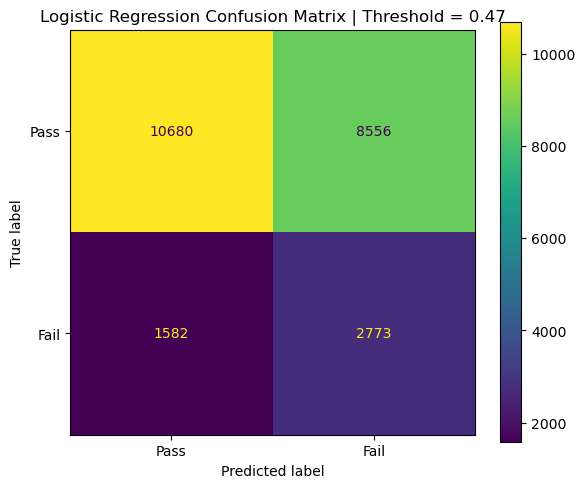

In [20]:
cm_best = confusion_matrix(y_test, y_pred_best)

fig, ax = plt.subplots(figsize=(6, 5))
disp = ConfusionMatrixDisplay(cm_best, display_labels=["Pass", "Fail"])
disp.plot(ax=ax, values_format="d")
plt.title(f"Logistic Regression Confusion Matrix | Threshold = {best_threshold:.2f}")
plt.tight_layout()
plt.savefig("figures/logistic_confusion_matrix_best_threshold.png", dpi=300, bbox_inches="tight")
plt.show()

## 11. Confusion Matrix Interpretation

The confusion matrix is interpreted in public-health terms:

- **True Positive:** The model correctly flags a failing restaurant.
- **True Negative:** The model correctly identifies a passing restaurant.
- **False Positive:** The model flags a restaurant as high-risk, but it actually passes. This may create unnecessary inspection workload.
- **False Negative:** The model predicts pass, but the restaurant actually fails. This is the most serious error because a risky restaurant may be missed.

Given the public-health context, the evaluation emphasizes **recall**, **F1-score**, and **ROC-AUC**, rather than accuracy alone.

## 12. Coefficient Interpretation

A major advantage of Logistic Regression is interpretability.

After preprocessing, the model coefficients show which variables are associated with higher or lower predicted failure risk.

- **Positive coefficients** increase predicted failure probability.
- **Negative coefficients** decrease predicted failure probability.

This makes Logistic Regression useful as an interpretable baseline, even if more complex models later achieve stronger predictive performance.

In [21]:
preprocessor_fitted = best_logistic_model.named_steps["preprocessor"]
model_fitted = best_logistic_model.named_steps["model"]

num_feature_names = numeric_features

cat_feature_names = list(
    preprocessor_fitted
    .named_transformers_["cat"]
    .named_steps["onehot"]
    .get_feature_names_out(categorical_features)
)

all_feature_names = num_feature_names + cat_feature_names

coef_df = pd.DataFrame({
    "feature": all_feature_names,
    "coefficient": model_fitted.coef_[0]
})

coef_df["abs_coefficient"] = coef_df["coefficient"].abs()
coef_df = coef_df.sort_values("abs_coefficient", ascending=False)

coef_df.head(20)

,feature,coefficient,abs_coefficient
43,cuisine_grouped_Donuts,-1.216862,1.216862
44,cuisine_grouped_Hamburgers,-0.704171,0.704171
41,cuisine_grouped_Chinese,0.540385,0.540385
49,cuisine_grouped_Korean,0.520449,0.520449
211,yelp_category_primary_restaurants,0.506060,0.506060
121,yelp_category_primary_dimsum,0.453940,0.453940
93,yelp_category_primary_burgers,0.452970,0.452970
178,yelp_category_primary_latin,-0.448204,0.448204
5,has_history,-0.446987,0.446987
50,cuisine_grouped_Latin American,0.440746,0.440746


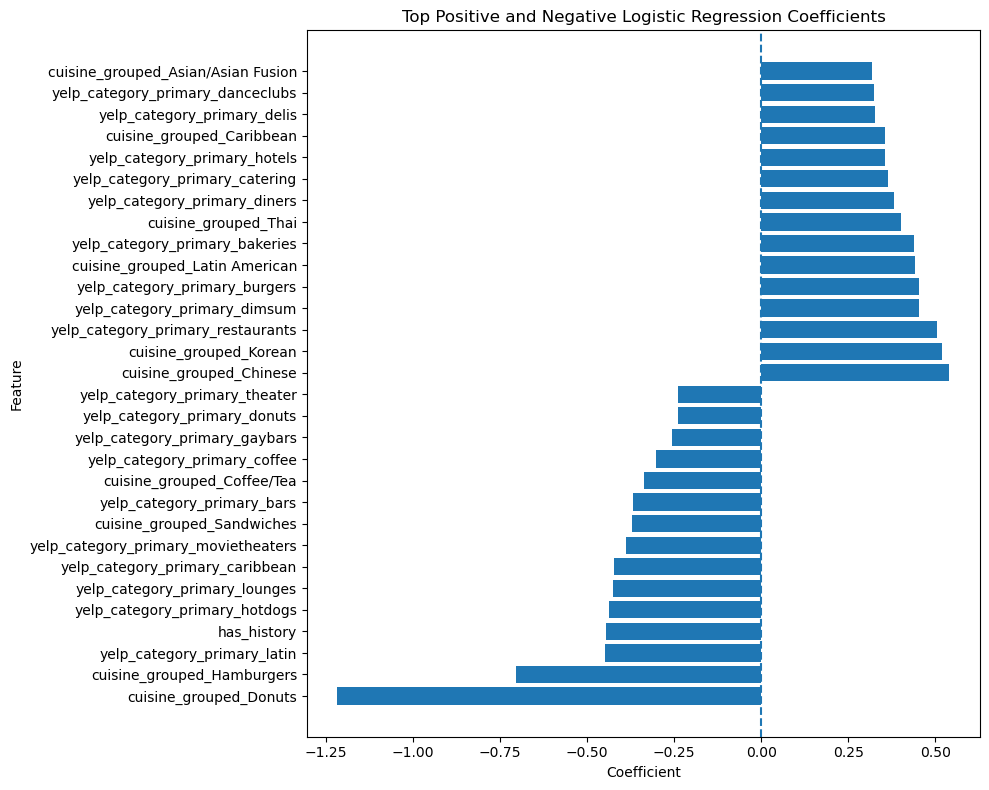

In [22]:
top_positive = coef_df.sort_values("coefficient", ascending=False).head(15)
top_negative = coef_df.sort_values("coefficient", ascending=True).head(15)

coef_plot_df = pd.concat([top_negative, top_positive])

plt.figure(figsize=(10, 8))
plt.barh(coef_plot_df["feature"], coef_plot_df["coefficient"])
plt.axvline(0, linestyle="--")
plt.title("Top Positive and Negative Logistic Regression Coefficients")
plt.xlabel("Coefficient")
plt.ylabel("Feature")
plt.tight_layout()
plt.savefig("figures/logistic_coefficient_plot.png", dpi=300, bbox_inches="tight")
plt.show()

In [25]:
# Convert coefficients to odds ratios for easier interpretation
odds_df = coef_df.copy()
odds_df["odds_ratio"] = np.exp(odds_df["coefficient"])

top_odds_positive = odds_df.sort_values("odds_ratio", ascending=False).head(15)
top_odds_negative = odds_df.sort_values("odds_ratio", ascending=True).head(15)

odds_display = pd.concat([top_odds_negative, top_odds_positive])
odds_display[["feature", "coefficient", "odds_ratio"]]

,feature,coefficient,odds_ratio
43,cuisine_grouped_Donuts,-1.216862,0.296158
44,cuisine_grouped_Hamburgers,-0.704171,0.494518
178,yelp_category_primary_latin,-0.448204,0.638774
5,has_history,-0.446987,0.639552
161,yelp_category_primary_hotdogs,-0.436322,0.646410
184,yelp_category_primary_lounges,-0.426558,0.652752
99,yelp_category_primary_caribbean,-0.424186,0.654302
193,yelp_category_primary_movietheaters,-0.387603,0.678682
54,cuisine_grouped_Sandwiches,-0.371078,0.689990
77,yelp_category_primary_bars,-0.367278,0.692617


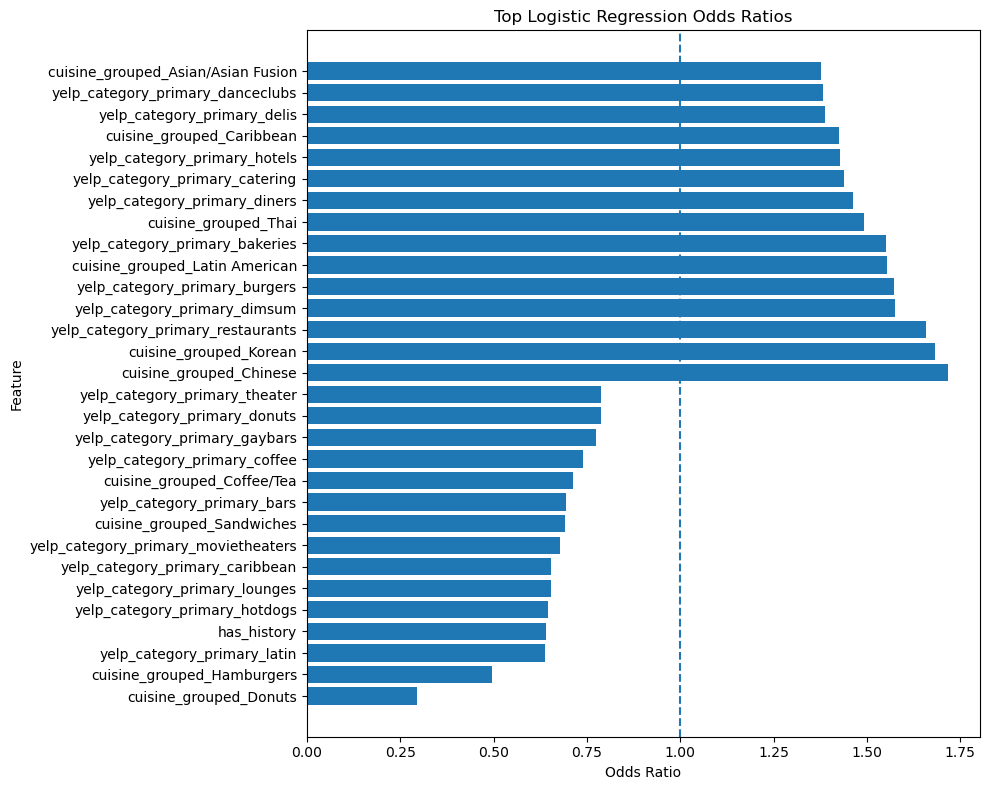

In [26]:
plt.figure(figsize=(10, 8))
plt.barh(odds_display["feature"], odds_display["odds_ratio"])
plt.axvline(1, linestyle="--")
plt.title("Top Logistic Regression Odds Ratios")
plt.xlabel("Odds Ratio")
plt.ylabel("Feature")
plt.tight_layout()
plt.savefig("figures/logistic_odds_ratio_plot.png", dpi=300, bbox_inches="tight")
plt.show()

### Odds-Based Interpretation

To make coefficient interpretation more intuitive, we convert Logistic Regression coefficients into **odds ratios**.

An odds ratio greater than 1 means that the feature is associated with higher odds of inspection failure, holding other variables constant. An odds ratio less than 1 means that the feature is associated with lower odds of inspection failure.

This interpretation is useful because it connects the statistical model to policy communication. Instead of only saying that a coefficient is positive or negative, we can explain whether a feature increases or decreases the estimated odds of failure under the **ceteris paribus** assumption.

## 13. Business Interpretation

The coefficient plot translates the baseline model into practical risk signals.

Features with positive coefficients are associated with higher inspection-failure risk. These may reflect poor historical inspection performance, complaint pressure, seasonal context, or high-risk restaurant categories.

Features with negative coefficients are associated with lower failure risk. These may reflect more stable inspection history, lower complaint intensity, or lower-risk operating contexts.

The purpose of this model is not only to predict failure, but also to provide a transparent risk-screening framework that can support public-health decision-making.

## 14. Public-Health Recommendations

Based on the leakage-safe feature engineering and Logistic Regression interpretation, this model can support an early-warning system for restaurant inspection risk.

**For NYC health inspectors:**

- Prioritize restaurants with poor prior inspection history.
- Monitor restaurants in high complaint-density environments.
- Use complaint density instead of raw complaint count to account for borough population size.
- Pay attention to temporal patterns such as seasonality and weekend effects.
- Emphasize recall to reduce the chance of missing truly failing restaurants.

**For restaurant operators:**

- Improve consistency across repeated inspections.
- Monitor customer and civic complaint patterns.
- Address historical risk signals before future inspections.
- Prepare more carefully during higher-risk seasonal periods.

Overall, this section transforms cleaned multi-source data into a reproducible and interpretable baseline prediction pipeline.

In [27]:
# Save model
joblib.dump(best_logistic_model, "models/logistic_model.pkl")

# Save feature-engineered dataset
df_fe.to_csv("outputs/restaurant_feature_engineered_leakage_safe.csv", index=False)

# Save leakage audit
leakage_audit.to_csv("outputs/leakage_audit.csv", index=False)

# Save metrics
comparison_metrics.to_csv("outputs/logistic_regression_metrics_threshold_comparison.csv")

# Save coefficients
coef_df.to_csv("outputs/logistic_regression_coefficients.csv", index=False)

# Save threshold tuning results
threshold_df.to_csv("outputs/logistic_threshold_tuning.csv", index=False)

baseline_comparison.to_csv("outputs/baseline_vs_logistic_metrics.csv")
odds_df.to_csv("outputs/logistic_regression_odds_ratios.csv", index=False)

print("Saved final Part C outputs:")
print("- models/logistic_model.pkl")
print("- outputs/restaurant_feature_engineered_leakage_safe.csv")
print("- outputs/leakage_audit.csv")
print("- outputs/logistic_regression_metrics_threshold_comparison.csv")
print("- outputs/logistic_regression_coefficients.csv")
print("- outputs/logistic_threshold_tuning.csv")
print("- figures/logistic_confusion_matrix_default.png")
print("- figures/logistic_confusion_matrix_best_threshold.png")
print("- figures/logistic_roc_curve.png")
print("- figures/logistic_threshold_tuning.png")
print("- figures/logistic_coefficient_plot.png")
print("- outputs/baseline_vs_logistic_metrics.csv")
print("- outputs/logistic_regression_odds_ratios.csv")
print("- figures/logistic_odds_ratio_plot.png")

Saved final Part C outputs:
- models/logistic_model.pkl
- outputs/restaurant_feature_engineered_leakage_safe.csv
- outputs/leakage_audit.csv
- outputs/logistic_regression_metrics_threshold_comparison.csv
- outputs/logistic_regression_coefficients.csv
- outputs/logistic_threshold_tuning.csv
- figures/logistic_confusion_matrix_default.png
- figures/logistic_confusion_matrix_best_threshold.png
- figures/logistic_roc_curve.png
- figures/logistic_threshold_tuning.png
- figures/logistic_coefficient_plot.png
- outputs/baseline_vs_logistic_metrics.csv
- outputs/logistic_regression_odds_ratios.csv
- figures/logistic_odds_ratio_plot.png


## Part C Summary

This section developed the **leakage-safe feature engineering, preprocessing, and interpretable Logistic Regression baseline** for restaurant inspection failure prediction.

The main contributions are:

1. **Leakage prevention:** Current inspection outcome variables such as score, grade, violation count, critical count, score trend, and cluster labels derived from them were excluded.
2. **Feature engineering:** Historical risk, complaint environment, temporal context, weather, demographic, and Yelp visibility variables were transformed into modeling features.
3. **Time-based validation:** The model was trained on 2023 inspections and tested on 2024 inspections to simulate real-world deployment.
4. **Reproducible preprocessing:** Missing-value imputation, standardization, and one-hot encoding were handled using sklearn pipelines.
5. **Regularized Logistic Regression:** The baseline model was tuned using cross-validation and class weighting.
6. **Threshold tuning:** The decision threshold was adjusted to better balance precision, recall, and F1-score.
7. **Interpretability:** Coefficient analysis was used to identify transparent risk signals for inspection failure.

This part connects the multi-source data preparation and exploratory findings to the supervised modeling stage, while maintaining a strict separation between pre-inspection predictors and post-inspection outcomes.